In [2]:
# =========================
# Decision Tree Regressor — NVDA Monthly LOG Return Forecast (2010–2025)
# Robust yfinance loading for column formats like: "Close NVDA", "High NVDA", ...
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.tree import DecisionTreeRegressor, export_text
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance

C:\Users\Auror\AppData\Local\Temp\ipykernel_16760\1723920760.py:39: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  nvda_m = nvda_px.resample("M").last().to_frame("NVDA")
C:\Users\Auror\AppData\Local\Temp\ipykernel_16760\1723920760.py:40: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  spy_m  = spy_px.resample("M").last().to_frame("SPY")


Baseline (0 log return)         MAE=0.111423  RMSE=0.137189

Best params: {'max_depth': 4, 'min_samples_leaf': 5, 'min_samples_split': 2}
Decision Tree (train)           MAE=0.076708  RMSE=0.100175
Decision Tree (test)            MAE=0.128873  RMSE=0.169772

Generalization gap (RMSE test - train): 0.069597
RMSE improvement vs baseline: -0.032583 (positive = better)
MAE  improvement vs baseline: -0.017450 (positive = better)


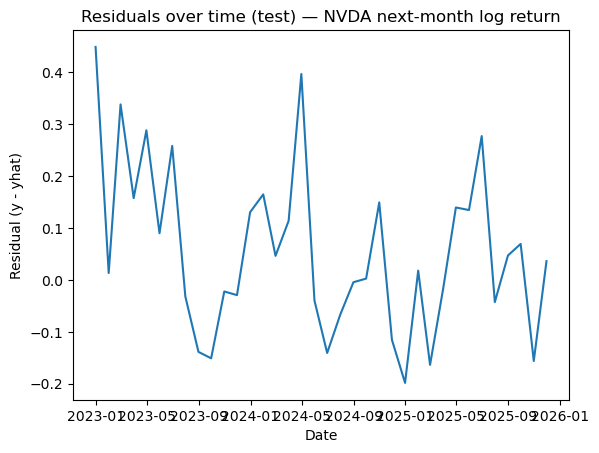

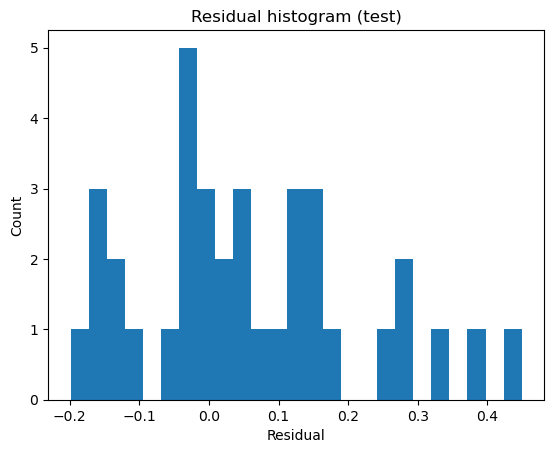


Permutation importance (higher = more important):
spy_lr_lag1            0.141296
nvda_mom_12            0.012673
spy_lr_lag3            0.000000
nvda_lr_roll_mean_6    0.000000
nvda_lr_lag6           0.000000
nvda_lr_roll_mean_3    0.000000
nvda_mom_6            -0.023579
nvda_lr_lag3          -0.029164
spy_lr_lag6           -0.301289
nvda_lr_lag1          -0.365905
dtype: float64


In [3]:
# -------------------------
# Helper: robustly get a single price series from yfinance output
# Handles:
#   - normal columns: "Adj Close", "Close"
#   - flattened multiindex: "Adj Close NVDA", "Close NVDA"
# -------------------------
def get_price_series(ticker: str, start: str, end: str) -> pd.Series:
    raw = yf.download(ticker, start=start, end=end, progress=False)

    # If columns are MultiIndex, flatten to strings
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = [" ".join([str(x) for x in col if x != ""]).strip() for col in raw.columns]

    # Candidate column names to try, in priority order
    candidates = [
        "Adj Close",                # standard
        f"Adj Close {ticker}",      # flattened form
        "Close",                    # fallback
        f"Close {ticker}"           # flattened form
    ]

    for col in candidates:
        if col in raw.columns:
            s = raw[col].copy().dropna()
            s.name = ticker
            return s

    raise KeyError(f"{ticker}: price column not found. Columns = {list(raw.columns)}")


# -------------------------
# 1) Load daily prices and resample to monthly
# -------------------------
start, end = "2010-01-01", "2025-12-31"

nvda_px = get_price_series("NVDA", start, end)
spy_px  = get_price_series("SPY",  start, end)

nvda_m = nvda_px.resample("M").last().to_frame("NVDA")
spy_m  = spy_px.resample("M").last().to_frame("SPY")

df = nvda_m.join(spy_m, how="inner").dropna()


# -------------------------
# 2) Monthly log returns + target
# -------------------------
df["log_NVDA"] = np.log(df["NVDA"])
df["log_SPY"]  = np.log(df["SPY"])

df["nvda_lr_m"] = df["log_NVDA"].diff()
df["spy_lr_m"]  = df["log_SPY"].diff()

# Target: next-month NVDA log return
df["y_next_nvda_lr_m"] = df["nvda_lr_m"].shift(-1)


# -------------------------
# 3) Features (consistent timing)
# -------------------------
# NVDA lagged monthly returns
df["nvda_lr_lag1"] = df["nvda_lr_m"].shift(1)
df["nvda_lr_lag3"] = df["nvda_lr_m"].shift(3)
df["nvda_lr_lag6"] = df["nvda_lr_m"].shift(6)

# Rolling mean of returns (trend proxy), past-only window ending at t-1
df["nvda_lr_roll_mean_3"] = df["nvda_lr_m"].shift(1).rolling(3).mean()
df["nvda_lr_roll_mean_6"] = df["nvda_lr_m"].shift(1).rolling(6).mean()

# Momentum at time t (simple)
df["nvda_mom_6"]  = df["log_NVDA"] - df["log_NVDA"].shift(6)
df["nvda_mom_12"] = df["log_NVDA"] - df["log_NVDA"].shift(12)

# SPY lagged monthly returns (market context; lags only)
df["spy_lr_lag1"] = df["spy_lr_m"].shift(1)
df["spy_lr_lag3"] = df["spy_lr_m"].shift(3)
df["spy_lr_lag6"] = df["spy_lr_m"].shift(6)

df = df.dropna().copy()


# -------------------------
# 4) Build X and y
# -------------------------
feature_cols = [
    "nvda_lr_lag1", "nvda_lr_lag3", "nvda_lr_lag6",
    "nvda_lr_roll_mean_3", "nvda_lr_roll_mean_6",
    "nvda_mom_6", "nvda_mom_12",
    "spy_lr_lag1", "spy_lr_lag3", "spy_lr_lag6"
]

X = df[feature_cols]
y = df["y_next_nvda_lr_m"]


# -------------------------
# 5) Time-based train/test split (80/20)
# -------------------------
split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]


def report_errors(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name:<30}  MAE={mae:.6f}  RMSE={rmse:.6f}")
    return mae, rmse


# -------------------------
# 6) Baseline: predict 0
# -------------------------
baseline_pred = np.zeros_like(y_test.values)
baseline_mae, baseline_rmse = report_errors(y_test, baseline_pred, "Baseline (0 log return)")


# -------------------------
# 7) Tune Decision Tree using TimeSeriesSplit
# -------------------------
tscv = TimeSeriesSplit(n_splits=4)

tree = DecisionTreeRegressor(random_state=42)
param_grid = {
    "max_depth": [2, 3, 4, None],
    "min_samples_leaf": [2, 5, 10],
    "min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(
    estimator=tree,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    n_jobs=-1
)
grid.fit(X_train, y_train)

best_tree = grid.best_estimator_
print("\nBest params:", grid.best_params_)


# -------------------------
# 8) Fit + forecast error check (MAE, RMSE)
# -------------------------
best_tree.fit(X_train, y_train)

pred_train = best_tree.predict(X_train)
pred_test  = best_tree.predict(X_test)

train_mae, train_rmse = report_errors(y_train, pred_train, "Decision Tree (train)")
test_mae,  test_rmse  = report_errors(y_test,  pred_test,  "Decision Tree (test)")

print("\nGeneralization gap (RMSE test - train):", f"{test_rmse - train_rmse:.6f}")
print("RMSE improvement vs baseline:", f"{baseline_rmse - test_rmse:.6f}", "(positive = better)")
print("MAE  improvement vs baseline:", f"{baseline_mae - test_mae:.6f}", "(positive = better)")


# -------------------------
# 9) Residual plots
# -------------------------
resid = y_test.values - pred_test

plt.figure()
plt.plot(y_test.index, resid)
plt.title("Residuals over time (test) — NVDA next-month log return")
plt.xlabel("Date")
plt.ylabel("Residual (y - yhat)")
plt.show()

plt.figure()
plt.hist(resid, bins=25)
plt.title("Residual histogram (test)")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.show()


# -------------------------
# 10) Permutation importance
# -------------------------
perm = permutation_importance(best_tree, X_test, y_test, n_repeats=20, random_state=42)
perm_imp = pd.Series(perm.importances_mean, index=feature_cols).sort_values(ascending=False)

print("\nPermutation importance (higher = more important):")
print(perm_imp)

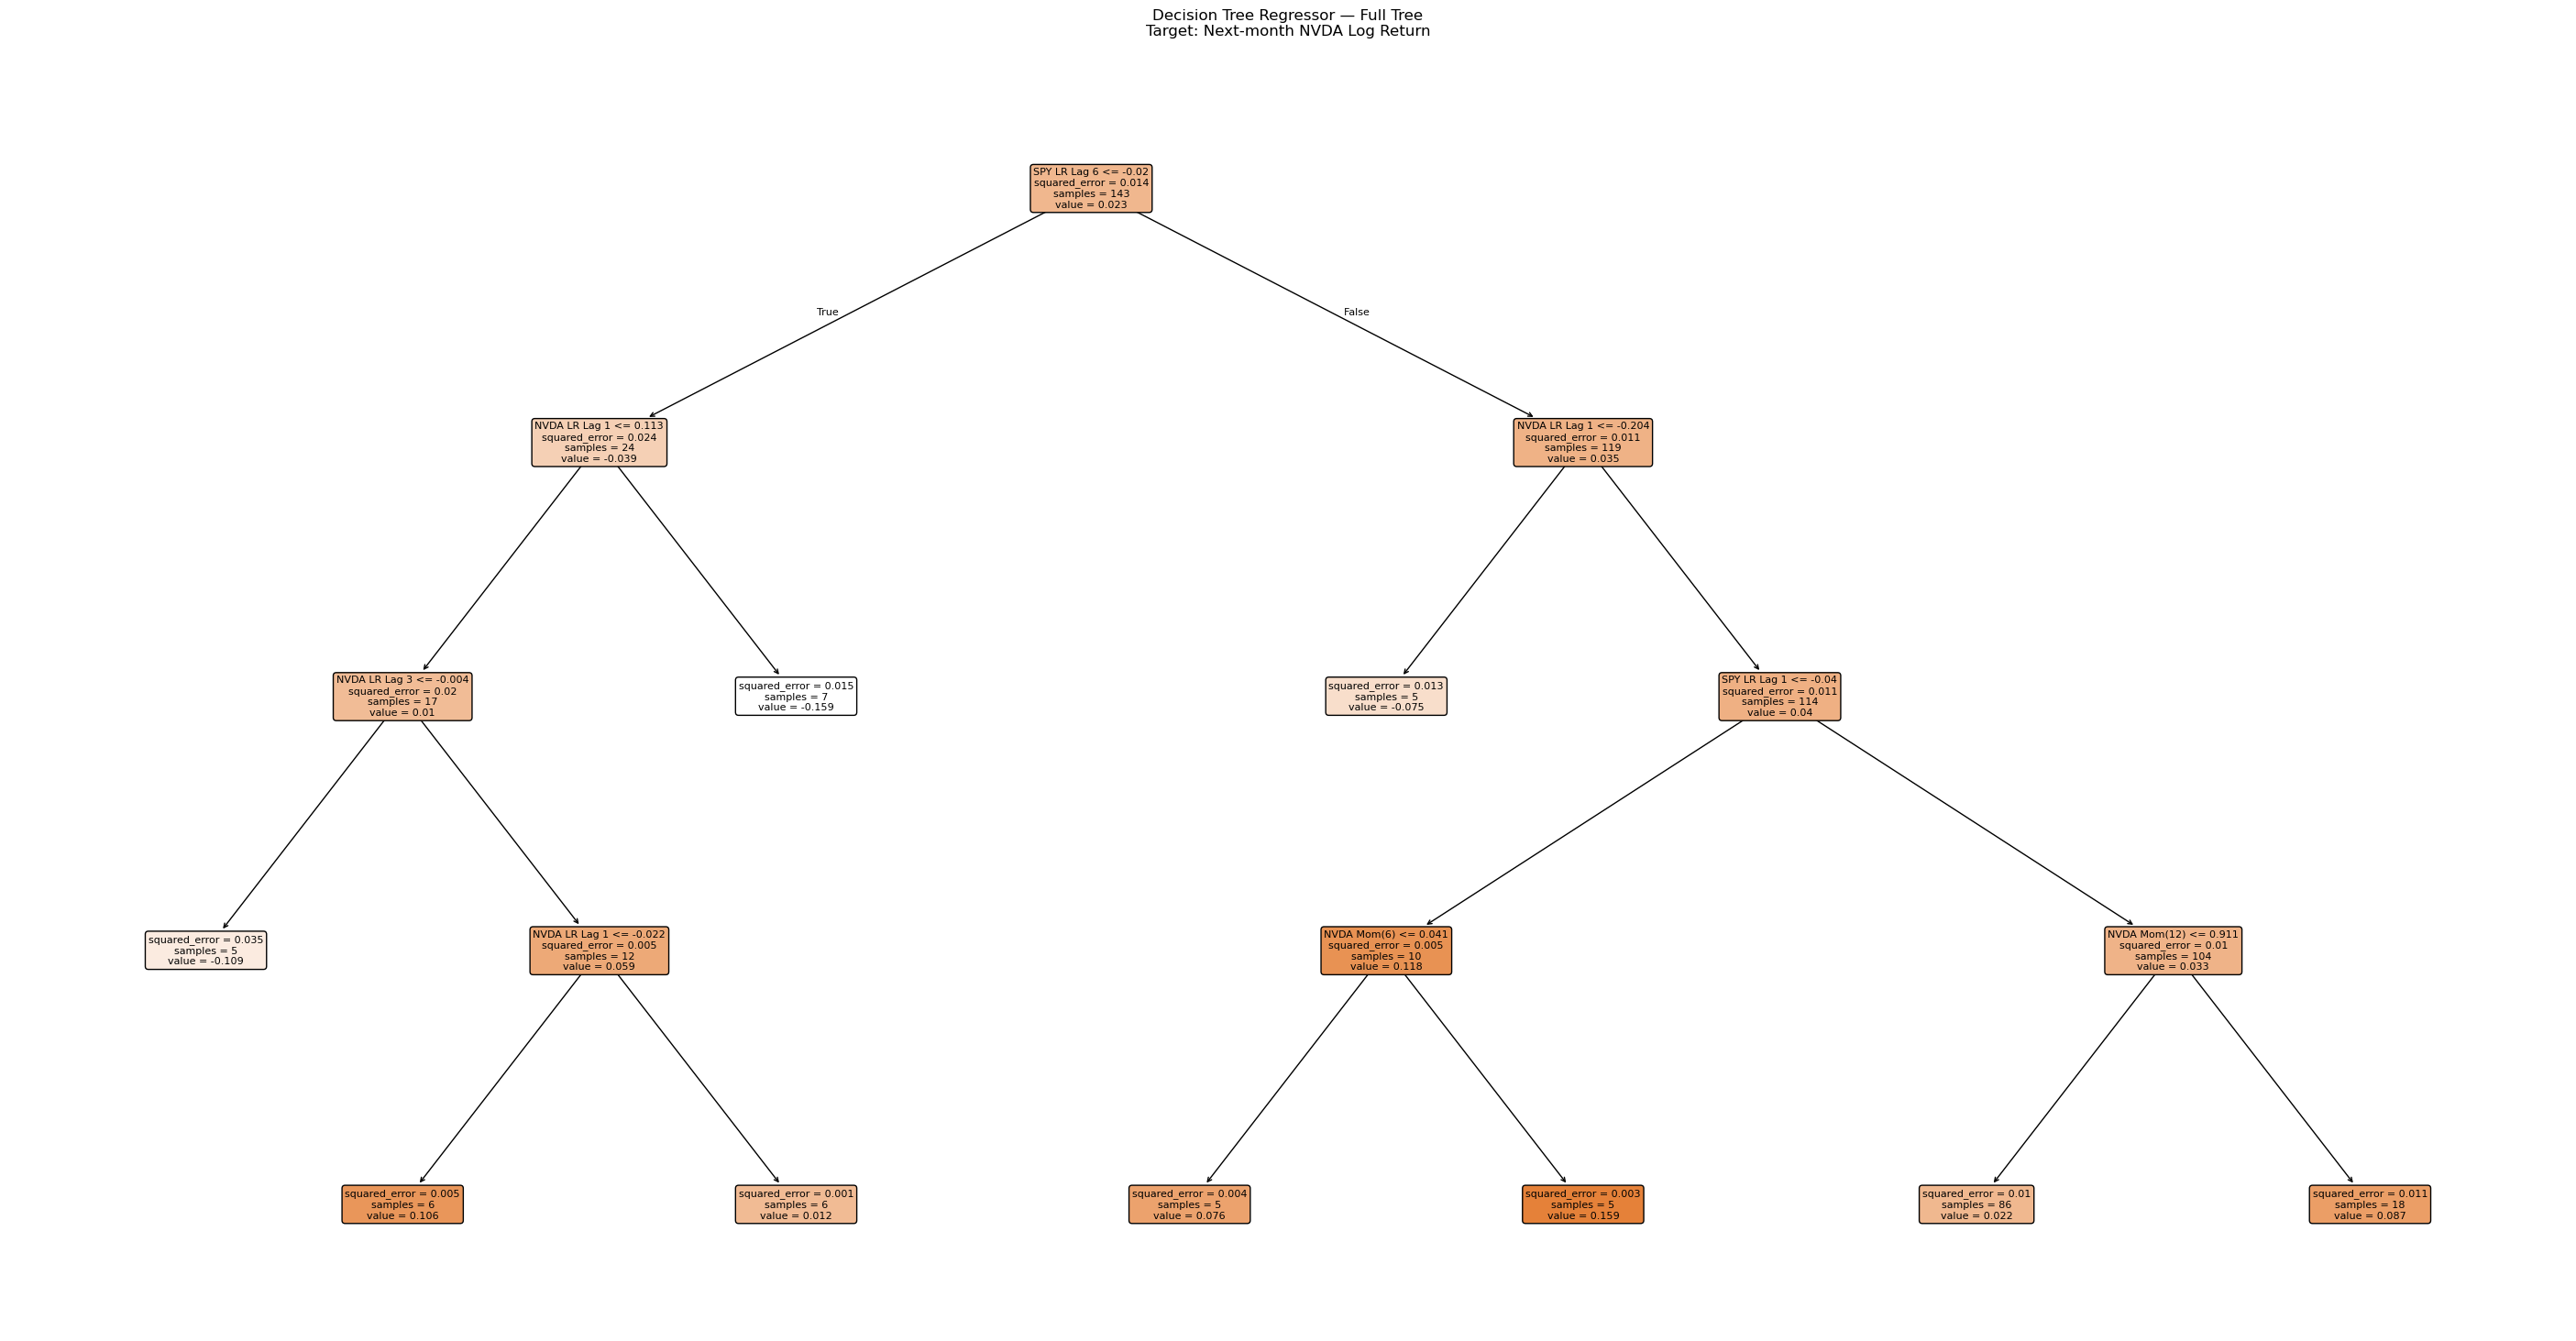

In [7]:
from sklearn.tree import plot_tree

# Pretty feature names for readability
pretty_names = {
    "nvda_lr_lag1": "NVDA LR Lag 1",
    "nvda_lr_lag3": "NVDA LR Lag 3",
    "nvda_lr_lag6": "NVDA LR Lag 6",
    "nvda_lr_roll_mean_3": "NVDA LR Mean(3)",
    "nvda_lr_roll_mean_6": "NVDA LR Mean(6)",
    "nvda_mom_6": "NVDA Mom(6)",
    "nvda_mom_12": "NVDA Mom(12)",
    "spy_lr_lag1": "SPY LR Lag 1",
    "spy_lr_lag3": "SPY LR Lag 3",
    "spy_lr_lag6": "SPY LR Lag 6"
}

display_feature_cols = [pretty_names[c] for c in feature_cols]

# -------------------------
# Plot FULL tree
# -------------------------
plt.figure(figsize=(36, 18))  # very large for full tree readability

plot_tree(
    best_tree,
    feature_names=display_feature_cols,
    filled=True,
    rounded=True,
    fontsize=8,      # smaller font so all labels fit
    impurity=True,   # show MSE
    proportion=False # show sample counts instead of proportions
)

plt.title("Decision Tree Regressor — Full Tree\nTarget: Next-month NVDA Log Return", pad=20)

# Save high-resolution image for zooming in report
plt.savefig("nvda_tree_full.png", dpi=300, bbox_inches="tight")

plt.show()



=== Performance Summary ===
                Split      MAE     RMSE        R2
      Baseline (Test) 0.111423 0.137189 -0.364657
Decision Tree (Train) 0.076708 0.100175  0.290546
 Decision Tree (Test) 0.128873 0.169772 -1.089857

=== Key Comparisons (Test) ===
RMSE improvement vs baseline: -0.032583 (positive = better)
MAE  improvement vs baseline: -0.017450 (positive = better)
Generalization gap (RMSE test - train): 0.069597
Generalization gap (MAE  test - train): 0.052165


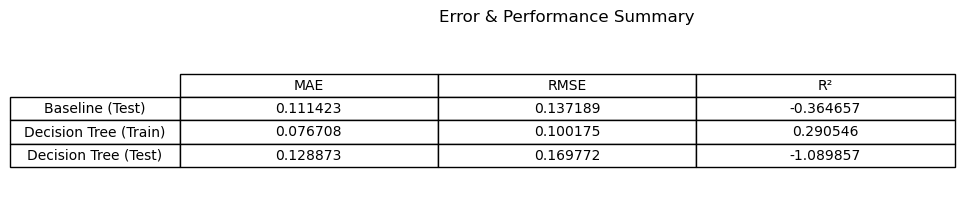

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import plot_tree

# -------------------------
# Helper: error metrics
# -------------------------
def metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2


# -------------------------
# 1) Summary table (Baseline vs Train vs Test)
# -------------------------
train_mae, train_rmse, train_r2 = metrics(y_train, pred_train)
test_mae,  test_rmse,  test_r2  = metrics(y_test,  pred_test)

base_mae, base_rmse, base_r2 = metrics(y_test, baseline_pred)  # baseline evaluated on TEST

summary = pd.DataFrame({
    "Split": ["Baseline (Test)", "Decision Tree (Train)", "Decision Tree (Test)"],
    "MAE":   [base_mae, train_mae, test_mae],
    "RMSE":  [base_rmse, train_rmse, test_rmse],
    "R2":    [base_r2, train_r2, test_r2],
})

# Add useful comparisons
generalization_gap_rmse = test_rmse - train_rmse
generalization_gap_mae  = test_mae  - train_mae

rmse_improve_vs_base = base_rmse - test_rmse
mae_improve_vs_base  = base_mae  - test_mae

print("\n=== Performance Summary ===")
print(summary.to_string(index=False))

print("\n=== Key Comparisons (Test) ===")
print(f"RMSE improvement vs baseline: {rmse_improve_vs_base:.6f} (positive = better)")
print(f"MAE  improvement vs baseline: {mae_improve_vs_base:.6f} (positive = better)")
print(f"Generalization gap (RMSE test - train): {generalization_gap_rmse:.6f}")
print(f"Generalization gap (MAE  test - train): {generalization_gap_mae:.6f}")


# Optional: show as a nicely formatted table plot (no external packages)
plt.figure(figsize=(10, 2.2))
plt.axis("off")
tbl = plt.table(
    cellText=np.round(summary[["MAE","RMSE","R2"]].values, 6),
    colLabels=["MAE","RMSE","R²"],
    rowLabels=summary["Split"].tolist(),
    cellLoc="center",
    rowLoc="center",
    loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.4)
plt.title("Error & Performance Summary", pad=10)
plt.show()


